# Machine Learning Model Development and Evaluation

This notebook focuses on developing, training, evaluating, and selecting the best machine learning model for predicting whether an online shopping session will result in a purchase.

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import joblib

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Processed Dataset


In [50]:
# Load the processed training and testing datasets

X_train = pd.read_csv("../data/processed/X_train_processed.csv")
X_test = pd.read_csv("../data/processed/X_test_processed.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (9764, 34)
Testing features shape: (2441, 34)
Training target shape: (9764,)
Testing target shape: (2441,)


## 3. Target Variable Distribution

In [51]:
print("Training target distribution:")
print(y_train.value_counts())

print("\nTraining target percentage:")
print(y_train.value_counts(normalize=True) * 100)

Training target distribution:
Revenue
False    8238
True     1526
Name: count, dtype: int64

Training target percentage:
Revenue
False    84.371159
True     15.628841
Name: proportion, dtype: float64


## 4. Model Training

Several classification algorithms are trained and compared to identify the most suitable model for predicting online purchase intention.

In [52]:
# Initialize machine learning models

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

print("Models initialized successfully.")

Models initialized successfully.


In [53]:
trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    
    model.fit(X_train, y_train)
    trained_models[name] = model

print("\nAll models trained successfully.")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...

All models trained successfully.


## 5. Model Predictions

In [54]:
predictions = {}
probabilities = {}

for name, model in trained_models.items():
    predictions[name] = model.predict(X_test)
    probabilities[name] = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


## 6. Model Evaluation

In [55]:
results = []

for name in trained_models.keys():

    y_pred = predictions[name]
    y_prob = probabilities[name]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

results_df = pd.DataFrame(results)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.886932   0.767677  0.397906  0.524138  0.901658
1        Decision Tree  0.857435   0.542500  0.568063  0.554987  0.739592
2        Random Forest  0.905367   0.764912  0.570681  0.653673  0.923408


In [56]:
results_df = results_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0        Random Forest  0.905367   0.764912  0.570681  0.653673  0.923408
1        Decision Tree  0.857435   0.542500  0.568063  0.554987  0.739592
2  Logistic Regression  0.886932   0.767677  0.397906  0.524138  0.901658


In [57]:
best_model_name = "Logistic Regression"

best_model = trained_models[best_model_name]

print("Selected Final Model:", best_model_name)

Selected Final Model: Logistic Regression


In [58]:
best_row = results_df[
    results_df["Model"] == best_model_name
].iloc[0]

print("\nFinal Model Performance:")

print("Accuracy :", round(best_row["Accuracy"], 4))
print("Precision:", round(best_row["Precision"], 4))
print("Recall   :", round(best_row["Recall"], 4))
print("F1-Score :", round(best_row["F1-Score"], 4))
print("ROC-AUC  :", round(best_row["ROC-AUC"], 4))


Final Model Performance:
Accuracy : 0.8869
Precision: 0.7677
Recall   : 0.3979
F1-Score : 0.5241
ROC-AUC  : 0.9017


## 8. Confusion Matrix

A confusion matrix is used to evaluate the performance of the selected final model.

It shows the number of correctly and incorrectly classified instances for the two classes:

- No Purchase
- Purchase

The four outcomes are True Positive (TP), True Negative (TN), False Positive (FP), and False Negative (FN).

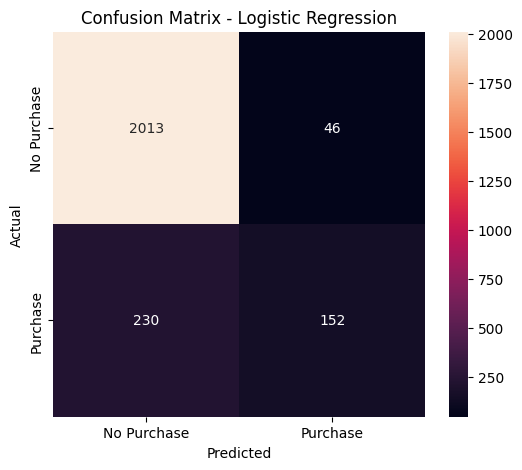

In [59]:
# Generate predictions using the final model

y_pred_best = best_model.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Purchase", "Purchase"],
    yticklabels=["No Purchase", "Purchase"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")

plt.show()

## 9. Classification Report

The classification report provides detailed performance metrics for the selected final model.

The main evaluation metrics are:

- Precision
- Recall
- F1-Score
- Support

These metrics help evaluate how effectively the model identifies customers who make a purchase and those who do not.

In [60]:
print(f"Classification Report - {best_model_name}\n")

print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=["No Purchase", "Purchase"],
        zero_division=0
    )
)

Classification Report - Logistic Regression

              precision    recall  f1-score   support

 No Purchase       0.90      0.98      0.94      2059
    Purchase       0.77      0.40      0.52       382

    accuracy                           0.89      2441
   macro avg       0.83      0.69      0.73      2441
weighted avg       0.88      0.89      0.87      2441



## 10. Save the Final Model

The selected Logistic Regression model is saved as a `.pkl` file using Joblib.

The saved model can later be loaded by the backend REST API to generate predictions for new customer sessions.

In [61]:
import os
import joblib

# Create models directory if it does not exist
os.makedirs("../models", exist_ok=True)

# Save the final model
joblib.dump(
    best_model,
    "../models/final_model.pkl"
)

print("Final model saved successfully.")
print("Model:", best_model_name)

Final model saved successfully.
Model: Logistic Regression


## 11. Load and Test the Saved Model

The saved model is loaded again to verify that it can successfully generate predictions.

This ensures that the model has been saved correctly and is ready for integration with the backend application.

In [62]:
# Load the saved model

loaded_model = joblib.load(
    "../models/final_model.pkl"
)

# Generate predictions for sample test records
sample_predictions = loaded_model.predict(
    X_test.iloc[:5]
)

print("Sample predictions:")
print(sample_predictions)

print("\nSaved model loaded and tested successfully.")

Sample predictions:
[False False False False False]

Saved model loaded and tested successfully.


## 12. Model Development Summary

Three supervised classification algorithms were trained and evaluated:

1. Logistic Regression
2. Decision Tree
3. Random Forest

The models were compared using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

Although Random Forest achieved higher overall predictive performance, Logistic Regression was selected as the final model because it is simple, interpretable, computationally efficient, and suitable for the binary classification problem.

The final Logistic Regression model was saved as `final_model.pkl` for future integration with the backend REST API.

## 13. Create Final ML Pipeline

The preprocessing steps and the Logistic Regression model are combined into a single machine learning pipeline.

This ensures that the same preprocessing transformations used during training are automatically applied to new input data before generating predictions.

The complete pipeline will be saved for integration with the backend REST API.

In [63]:
# Load the original dataset

df_raw = pd.read_csv(
    "../dataset/online_shoppers_intention.csv"
)

print("Raw dataset shape:", df_raw.shape)

Raw dataset shape: (12330, 18)


In [64]:
# Remove duplicate records

df_raw = df_raw.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df_raw.shape)
print("Duplicate records:", df_raw.duplicated().sum())

Dataset shape after removing duplicates: (12205, 18)
Duplicate records: 0


In [65]:
# Create engineered features

df_raw['TotalPages'] = (
    df_raw['Administrative']
    + df_raw['Informational']
    + df_raw['ProductRelated']
)

df_raw['TotalDuration'] = (
    df_raw['Administrative_Duration']
    + df_raw['Informational_Duration']
    + df_raw['ProductRelated_Duration']
)

df_raw['AvgProductDuration'] = (
    df_raw['ProductRelated_Duration']
    / df_raw['ProductRelated'].replace(0, 1)
)

df_raw['AvgAdministrativeDuration'] = (
    df_raw['Administrative_Duration']
    / df_raw['Administrative'].replace(0, 1)
)

df_raw['AvgInformationalDuration'] = (
    df_raw['Informational_Duration']
    / df_raw['Informational'].replace(0, 1)
)

print("Feature engineering completed.")
print("Dataset shape:", df_raw.shape)

Feature engineering completed.
Dataset shape: (12205, 23)


In [66]:
# Separate features and target

X_raw = df_raw.drop('Revenue', axis=1)
y_raw = df_raw['Revenue']

print("Features shape:", X_raw.shape)
print("Target shape:", y_raw.shape)

Features shape: (12205, 22)
Target shape: (12205,)


In [67]:
from sklearn.model_selection import train_test_split

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw,
    y_raw,
    test_size=0.20,
    random_state=42,
    stratify=y_raw
)

print("Raw training features shape:", X_train_raw.shape)
print("Raw testing features shape:", X_test_raw.shape)

Raw training features shape: (9764, 22)
Raw testing features shape: (2441, 22)


## 14. Create Final ML Pipeline

The preprocessing steps and the Logistic Regression classifier are combined into a single machine learning pipeline.

This pipeline applies the same preprocessing steps to new input data before generating predictions.

The complete pipeline is saved for integration with the backend REST API.

In [68]:
import joblib

# Load the saved preprocessing pipeline
preprocessor = joblib.load(
    "../models/preprocessor.pkl"
)

print("Preprocessor loaded successfully.")

Preprocessor loaded successfully.


In [69]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import joblib
import os

# Create the complete ML pipeline
final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Train the complete pipeline using raw training data
final_pipeline.fit(
    X_train_raw,
    y_train_raw
)

print("Final ML pipeline trained successfully.")

Final ML pipeline trained successfully.


## 15. Test the Final ML Pipeline

The trained pipeline is tested using the raw testing dataset.

The pipeline automatically performs the required preprocessing and then generates the final purchase intention prediction.

In [70]:
# Generate predictions using the final pipeline

pipeline_predictions = final_pipeline.predict(
    X_test_raw
)

pipeline_probabilities = final_pipeline.predict_proba(
    X_test_raw
)[:, 1]

print("Pipeline predictions generated successfully.")
print("Number of predictions:", len(pipeline_predictions))

Pipeline predictions generated successfully.
Number of predictions: 2441


## 16. Final Pipeline Evaluation

The final machine learning pipeline is evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

In [71]:
pipeline_accuracy = accuracy_score(
    y_test_raw,
    pipeline_predictions
)

pipeline_precision = precision_score(
    y_test_raw,
    pipeline_predictions,
    zero_division=0
)

pipeline_recall = recall_score(
    y_test_raw,
    pipeline_predictions,
    zero_division=0
)

pipeline_f1 = f1_score(
    y_test_raw,
    pipeline_predictions,
    zero_division=0
)

pipeline_roc_auc = roc_auc_score(
    y_test_raw,
    pipeline_probabilities
)

print("Final Pipeline Performance:")
print("Accuracy :", round(pipeline_accuracy, 4))
print("Precision:", round(pipeline_precision, 4))
print("Recall   :", round(pipeline_recall, 4))
print("F1-Score :", round(pipeline_f1, 4))
print("ROC-AUC  :", round(pipeline_roc_auc, 4))

Final Pipeline Performance:
Accuracy : 0.8894
Precision: 0.7718
Recall   : 0.4162
F1-Score : 0.5408
ROC-AUC  : 0.9021


## 17. Save the Final ML Pipeline

The complete preprocessing and Logistic Regression pipeline is saved as a `.pkl` file.

The saved pipeline can be loaded by the backend REST API and used to make predictions from raw customer session data.

In [72]:
# Create models directory if it does not exist
os.makedirs("../models", exist_ok=True)

# Save the complete pipeline
joblib.dump(
    final_pipeline,
    "../models/final_pipeline.pkl"
)

print("Final ML pipeline saved successfully.")
print("Saved file: ../models/final_pipeline.pkl")

Final ML pipeline saved successfully.
Saved file: ../models/final_pipeline.pkl
